In [ ]:
#data preprocessing
import pandas as pd
df=pd.read_csv('../1_processed_data/Cynthia Wong Streaming History 2024-2025.csv')
df

In [3]:
#AB test
#different platform(iOS vs Windows)

In [4]:
df['shuffle'] = df['shuffle'].astype(int)
df['skipped'] = df['skipped'].astype(int)
df

,ts,platform,min_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,reason_start,reason_end,shuffle,skipped
0,2024-09-17,windows,0.01,CN,Rockstar Made,Playboi Carti,Whole Lotta Red,playbtn,endplay,0,1
1,2024-09-17,windows,0.06,CN,Ocho Rios,Daniel Caesar,NEVER ENOUGH,playbtn,endplay,0,1
2,2024-09-17,windows,3.22,CN,Always,Daniel Caesar,NEVER ENOUGH,clickrow,trackdone,0,0
3,2024-09-17,windows,2.72,CN,Cool,Daniel Caesar,NEVER ENOUGH,trackdone,logout,0,0
4,2024-09-19,ios,0.02,CN,和每天講再見,Gin Lee,和每天講再見,clickrow,unexpected-exit-while-paused,0,0
...,...,...,...,...,...,...,...,...,...,...,...
4619,2025-05-21,windows,0.94,CN,SOMETHING ABOUT YOU,PARTYNEXTDOOR,$ome $exy $ongs 4 U,trackdone,unexpected-exit-while-paused,0,0
4620,2025-05-22,ios,0.00,US,月光,THOME,KILL THOME II,clickrow,unexpected-exit-while-paused,0,0
4621,2025-05-22,ios,0.03,US,CITY OF GOD,DONDA,DONDA 2,clickrow,endplay,0,1
4622,2025-05-22,ios,1.92,US,BURN EVERYTHING,DONDA,DONDA 2,clickrow,endplay,0,1


In [5]:
df['platform'] = df['platform'].map({'ios': 0, 'windows': 1})
df

,ts,platform,min_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,reason_start,reason_end,shuffle,skipped
0,2024-09-17,1,0.01,CN,Rockstar Made,Playboi Carti,Whole Lotta Red,playbtn,endplay,0,1
1,2024-09-17,1,0.06,CN,Ocho Rios,Daniel Caesar,NEVER ENOUGH,playbtn,endplay,0,1
2,2024-09-17,1,3.22,CN,Always,Daniel Caesar,NEVER ENOUGH,clickrow,trackdone,0,0
3,2024-09-17,1,2.72,CN,Cool,Daniel Caesar,NEVER ENOUGH,trackdone,logout,0,0
4,2024-09-19,0,0.02,CN,和每天講再見,Gin Lee,和每天講再見,clickrow,unexpected-exit-while-paused,0,0
...,...,...,...,...,...,...,...,...,...,...,...
4619,2025-05-21,1,0.94,CN,SOMETHING ABOUT YOU,PARTYNEXTDOOR,$ome $exy $ongs 4 U,trackdone,unexpected-exit-while-paused,0,0
4620,2025-05-22,0,0.00,US,月光,THOME,KILL THOME II,clickrow,unexpected-exit-while-paused,0,0
4621,2025-05-22,0,0.03,US,CITY OF GOD,DONDA,DONDA 2,clickrow,endplay,0,1
4622,2025-05-22,0,1.92,US,BURN EVERYTHING,DONDA,DONDA 2,clickrow,endplay,0,1


   platform  mean_min_played  median_min_played  count  skip_rate
0         0         1.703984              1.620   3582   0.570352
1         1         1.950240              2.005   1042   0.536468


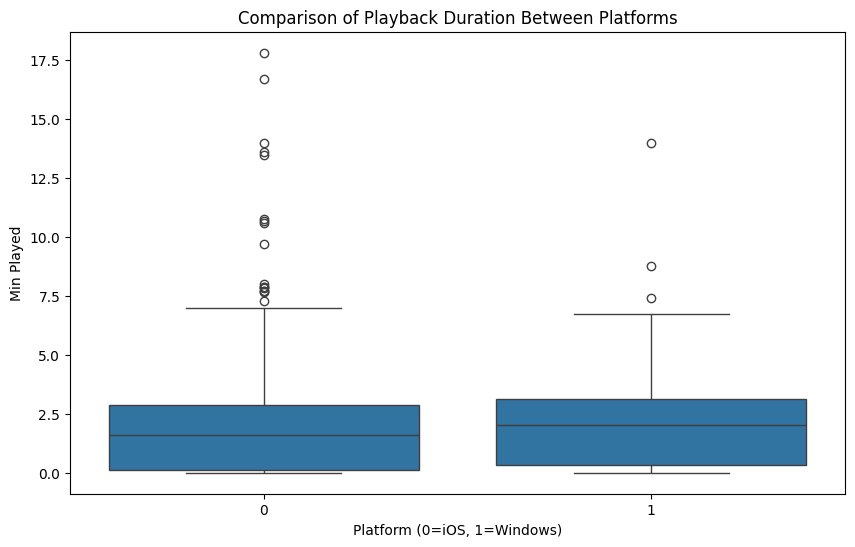

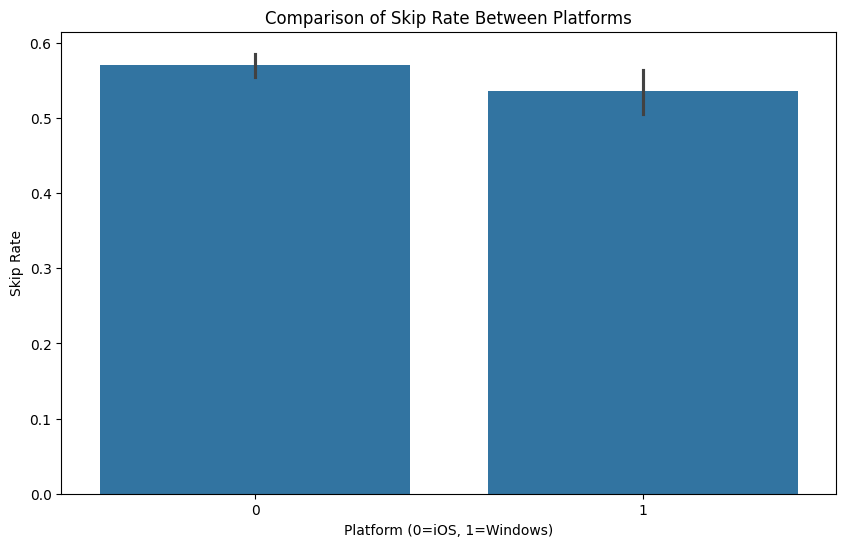

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Calculate the play duration and skip rate for each platform.
platform_data = df.groupby('platform').agg({
    'min_played': ['mean', 'median', 'count'],
    'skipped': 'mean'
}).reset_index()
platform_data.columns = ['platform', 'mean_min_played', 'median_min_played', 'count', 'skip_rate']

print(platform_data)

#Comparison of Playback Duration Between Platforms
plt.figure(figsize=(10, 6))
sns.boxplot(x='platform', y='min_played', data=df)
plt.xlabel('Platform (0=iOS, 1=Windows)')
plt.ylabel('Min Played')
plt.title('Comparison of Playback Duration Between Platforms')
plt.show()

#Comparison of Skip Rate Between Platforms
plt.figure(figsize=(10, 6))
sns.barplot(x='platform', y='skipped', data=df)
plt.xlabel('Platform (0=iOS, 1=Windows)')
plt.ylabel('Skip Rate')
plt.title('Comparison of Skip Rate Between Platforms')
plt.show()

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 统计检验：播放时长的t检验
t_stat, p_value = stats.ttest_ind(
    df[df['platform'] == 0]['min_played'],
    df[df['platform'] == 1]['min_played']
)
print(f"T-test for playback duration: t-statistic = {t_stat}, p-value = {p_value}")

# 统计检验：跳过率的卡方检验
contingency_table = pd.crosstab(df['platform'], df['skipped'])
if contingency_table.empty:
    print("Contingency table is empty. Check the data.")
else:
    chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"Chi-square test for skip rate: chi2 = {chi2}, p-value = {p_value_chi}")

T-test for playback duration: t-statistic = -4.367492022693014, p-value = 1.284318081050278e-05
Chi-square test for skip rate: chi2 = 3.6297064729893322, p-value = 0.056756825726778565
